In [1]:
import cftime
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

import matplotlib.patheffects as pe

from scipy import stats

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## fSST: Surface Temperature & net TOA Radiation anomalies

In [4]:
# --- read data --- 

ds_fSST = xr.open_dataset('./Fig6_fSST_TS_NetTOA.nc')

fSST_Pi_dtoa = ds_fSST['fSST_Pi_toa']      # Net TOA in response to dust changes (PI scenario)
fSST_Pi_dts = ds_fSST['fSST_Pi_ts']        # TS in response to dust changes (PI scenario)

fSST_Mio_dtoa = ds_fSST['fSST_Mio_toa']    # Net TOA in response to dust changes (Mio scenario)
fSST_Mio_dts = ds_fSST['fSST_Mio_ts']      # TS in response to dust changes (Mio scenario)

## FCM: Surface Temperature & net TOA Radiation anomalies
### Anomaly: respect to 2000~2500 yr. of reference case

In [5]:
# --- read data --- 

ds_FCM = xr.open_dataset('./Fig6_FCM_TS_NetTOA_Annual.nc')

FCM_Pi_dtoa = ds_FCM['FCM_Pi_Ano_toa_ANN']      # Net TOA in response to dust changes (PI scenario)
FCM_Pi_dts = ds_FCM['FCM_Pi_Ano_ts_ANN']        # TS in response to dust changes (PI scenario)

FCM_Mio_dtoa = ds_FCM['FCM_Mio_Ano_toa_ANN']    # Net TOA in response to dust changes (Mio scenario)
FCM_Mio_dts = ds_FCM['FCM_Mio_Ano_ts_ANN']      # TS in response to dust changes (Mio scenario)

In [6]:
FCM_Pi_dtoa_10yr = FCM_Pi_dtoa[0:50].copy()
FCM_Mio_dtoa_10yr = FCM_Mio_dtoa[0:50].copy()

tt = 0
while tt < 50:
    i = tt*10
    FCM_Pi_dtoa_10yr[tt] = FCM_Pi_dtoa[i: i+10].mean(dim=['year'])
    FCM_Mio_dtoa_10yr[tt] = FCM_Mio_dtoa[i: i+10].mean(dim=['year'])
    tt += 1

In [7]:
FCM_Pi_dts_10yr = FCM_Pi_dts[0:50].copy()
FCM_Mio_dts_10yr = FCM_Mio_dts[0:50].copy()

tt = 0
while tt < 50:
    i = tt*10
    FCM_Pi_dts_10yr[tt] = FCM_Pi_dts[i: i+10].mean(dim=['year'])
    FCM_Mio_dts_10yr[tt] = FCM_Mio_dts[i: i+10].mean(dim=['year'])
    tt += 1

## Calculate Corrected ERF

In [8]:
# For Miocene Dust ERF (Pi scenario)

x_Pi = FCM_Pi_dts
y_Pi = FCM_Pi_dtoa

p_Pi = np.polyfit(x_Pi[0:30], y_Pi[0:30], 1)
lambda_Pi, yintercept_Pi = p_Pi

fSST_Pi_dtoa_mean = fSST_Pi_dtoa.weighted(weights).mean(dim=['lon','lat']) 
fSST_Pi_dts_mean = fSST_Pi_dts.weighted(weights).mean(dim=['lon','lat']) 

Pi_ERF_corrected = fSST_Pi_dtoa_mean - lambda_Pi*fSST_Pi_dts_mean

print('<< Regional lambda (global temp) --- GeoPi.Dust* >>')
print('ERF= ', f'{fSST_Pi_dtoa_mean.values:.3f}')
print('ΔTland= ', f'{fSST_Pi_dts_mean.values:.3f}')
print('lambda= ', f'{lambda_Pi:.3f}')
print('ERFc= ', f'{Pi_ERF_corrected.values:.3f}')

<< Regional lambda (global temp) --- GeoPi.Dust* >>
ERF=  -0.006
ΔTland=  0.002
lambda=  -1.493
ERFc=  -0.003


In [9]:
# For Miocene Dust ERF (Mio scenario)

x_Mio = FCM_Mio_dts
y_Mio = FCM_Mio_dtoa

p_Mio = np.polyfit(x_Mio[0:30], y_Mio[0:30], 1)
lambda_Mio, yintercept_Mio = p_Mio

fSST_Mio_dtoa_mean = fSST_Mio_dtoa.weighted(weights).mean(dim=['lon','lat']) 
fSST_Mio_dts_mean = fSST_Mio_dts.weighted(weights).mean(dim=['lon','lat']) 

Mio_ERF_corrected = fSST_Mio_dtoa_mean - lambda_Mio*fSST_Mio_dts_mean

print('<< Regional lambda (global temp) --- GeoMio.Dust* >>')
print('ERF= ', f'{fSST_Mio_dtoa_mean.values:.3f}')
print('ΔTland= ', f'{fSST_Mio_dts_mean.values:.3f}')
print('lambda= ', f'{lambda_Mio:.3f}')
print('ERFc= ', f'{Mio_ERF_corrected.values:.3f}')

<< Regional lambda (global temp) --- GeoMio.Dust* >>
ERF=  0.143
ΔTland=  0.012
lambda=  -0.563
ERFc=  0.150


## Gregory Plot
### derived from decadal means (year 51-500)

/glade/derecho/scratch/pjchen/tmp/ipykernel_27346/1608682622.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[0].scatter(FCM_Pi_dts_10yr[5:], FCM_Pi_dtoa_10yr[5:], c = 'hotpink', cmap='viridis', marker='o', s=10)
/glade/derecho/scratch/pjchen/tmp/ipykernel_27346/1608682622.py:68: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs[1].scatter(FCM_Mio_dts_10yr[5:], FCM_Mio_dtoa_10yr[5:], c = 'skyblue', cmap='viridis', marker='o', s=10)


Text(0.5, 0.96, 'From bins of Decadal means (50-500 year)')

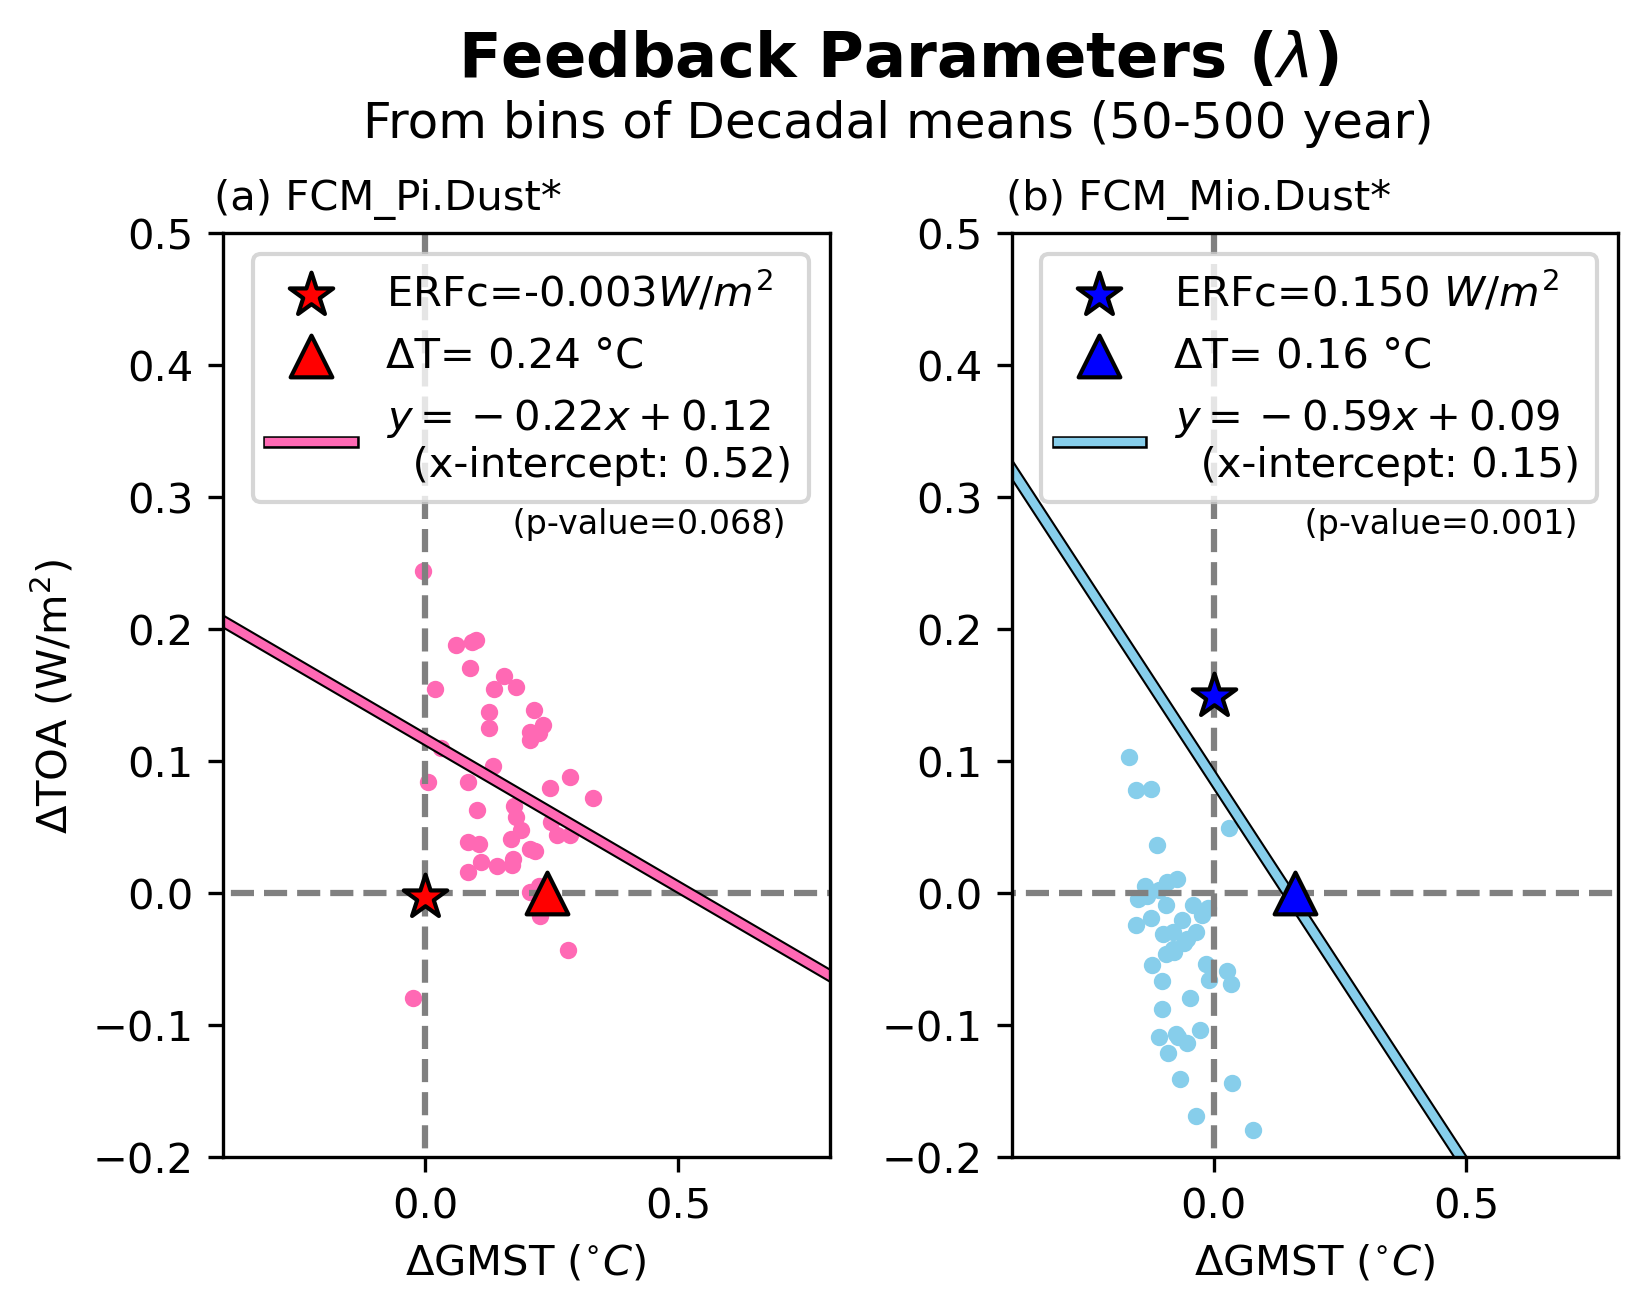

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(6, 4), dpi=300)
fig.subplots_adjust(wspace=0.3, hspace=0.05) 

# --- GeoPi_MioDust ---
axs[0].scatter(0, Pi_ERF_corrected.values, c = 'red', marker='*', s=120, edgecolors='black', linewidths=1.0, zorder=5)
axs[0].scatter(0.24, 0, c = 'red', marker='^', s=100, edgecolors='black', linewidths=1.0, zorder=5)    # ΔT obtained from Fig5a


# Calculate the regression line
x_Pi_after50_10yr = FCM_Pi_dts_10yr[5:]
y_Pi_after50_10yr = FCM_Pi_dtoa_10yr[5:]
p_Pi_after50_10yr = np.polyfit(x_Pi_after50_10yr, y_Pi_after50_10yr, 1)
lambda_Pi_after50_10yr, yintercept_Pi_after50_10yr = p_Pi_after50_10yr

line_Pi_after50_10yr = axs[0].axline(xy1=(0, yintercept_Pi_after50_10yr), slope=lambda_Pi_after50_10yr, 
                                     label=f'$y = {lambda_Pi_after50_10yr:.2f}x {yintercept_Pi_after50_10yr:+.2f}$', color='hotpink', linestyle='-', linewidth=2.0)
axs[0].scatter(FCM_Pi_dts_10yr[5:], FCM_Pi_dtoa_10yr[5:], c = 'hotpink', cmap='viridis', marker='o', s=10)
line_Pi_after50_10yr.set_path_effects([pe.Stroke(linewidth=3.0, foreground='black'),pe.Normal()])

axs[0].set_xlim([-0.4, 0.8])
axs[0].set_ylim([-0.2, 0.5])
axs[0].set_xlabel('ΔGMST ($^{\circ}C$)')
axs[0].set_ylabel('ΔTOA (W/m$^{2}$)')

axs[0].plot([-3,3], [0,0], "grey", linestyle='--', zorder=1)
axs[0].plot([0,0], [-3, 2.0], "grey", linestyle='--', zorder=1)


# Estimate p-value
y_Pi_after50_10yr_pred = np.polyval(p_Pi_after50_10yr, x_Pi_after50_10yr)
y_Pi_after50_10yr_res = y_Pi_after50_10yr - y_Pi_after50_10yr_pred
dof_Pi_after50_10yr = len(x_Pi_after50_10yr) - 2                # degree of freedom   
y_Pi_after50_10yr_res_std_error = np.sqrt(np.sum(y_Pi_after50_10yr_res**2) / dof_Pi_after50_10yr)
y_Pi_after50_10yr_slope_std_error = y_Pi_after50_10yr_res_std_error / np.sqrt(np.sum((x_Pi_after50_10yr - np.mean(x_Pi_after50_10yr))**2))
y_Pi_after50_10yr_t_stat = lambda_Pi_after50_10yr / y_Pi_after50_10yr_slope_std_error
y_Pi_after50_10yr_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Pi_after50_10yr_t_stat), df=dof_Pi_after50_10yr))


plt.figtext(0.12,0.9,'(a) FCM_Pi.Dust*',ha='left',fontsize=10)

text_Pi_after50_10yr = 'decadal (50~500yr.): '+ f'$y = {lambda_Pi_after50_10yr:.2f}x {yintercept_Pi_after50_10yr:+.2f}$'
pvalue_Pi_after50_10yr = ' (p-value='+str('{:03.3f}'.format(y_Pi_after50_10yr_pvalue))+')'

plt.figtext(0.28,0.63,pvalue_Pi_after50_10yr,ha='left',fontsize=8)

legend_Pi_ERF = 'ERFc='+f'{Pi_ERF_corrected.values:.3f}'+'$W/m^2$'
legend_Pi_T = 'ΔT= 0.24 °C'
xintercept_Pi_after50_10yr = (-yintercept_Pi_after50_10yr)/lambda_Pi_after50_10yr
legend_Pi_after50_10yr = f'$y = {lambda_Pi_after50_10yr:.2f}x {yintercept_Pi_after50_10yr:+.2f}$\n  (x-intercept: {xintercept_Pi_after50_10yr:.2f})'
legend = [legend_Pi_ERF, legend_Pi_T, legend_Pi_after50_10yr]
axs[0].legend(legend)


# ===============================================================================
# --- GeoMio_PiDust ---

axs[1].scatter(0, Mio_ERF_corrected.values, c = 'blue', marker='*', s=120, edgecolors='black', linewidths=1.0, zorder=5)
axs[1].scatter(0.16, 0, c = 'blue', marker='^', s=100, edgecolors='black', linewidths=1.0, zorder=5)

# Calculate the regression line
x_Mio_after50_10yr = -FCM_Mio_dts_10yr[5:]
y_Mio_after50_10yr = -FCM_Mio_dtoa_10yr[5:]
p_Mio_after50_10yr = np.polyfit(x_Mio_after50_10yr, y_Mio_after50_10yr, 1)
lambda_Mio_after50_10yr, yintercept_Mio_after50_10yr = p_Mio_after50_10yr

line_Mio_after50_10yr = axs[1].axline(xy1=(0, yintercept_Mio_after50_10yr), slope=lambda_Mio_after50_10yr, 
                                      label=f'$y = {lambda_Mio_after50_10yr:.2f}x {yintercept_Mio_after50_10yr:+.2f}$', color='skyblue', linestyle='-', linewidth=2.0)
axs[1].scatter(FCM_Mio_dts_10yr[5:], FCM_Mio_dtoa_10yr[5:], c = 'skyblue', cmap='viridis', marker='o', s=10)
line_Mio_after50_10yr.set_path_effects([pe.Stroke(linewidth=3.0, foreground='black'),pe.Normal()])


axs[1].set_xlim([-0.4, 0.8])
axs[1].set_ylim([-0.2, 0.5])
axs[1].set_xlabel('ΔGMST ($^{\circ}C$)')
axs[1].set_ylabel('')

axs[1].plot([-3,3], [0,0], "grey", linestyle='--', zorder=1)
axs[1].plot([0,0], [-3, 2.0], "grey", linestyle='--', zorder=1)


# Estimate p-value
y_Mio_after50_10yr_pred = np.polyval(p_Mio_after50_10yr, x_Mio_after50_10yr)
y_Mio_after50_10yr_res = y_Mio_after50_10yr - y_Mio_after50_10yr_pred
dof_Mio_after50_10yr = len(x_Mio_after50_10yr) - 2  
y_Mio_after50_10yr_res_std_error = np.sqrt(np.sum(y_Mio_after50_10yr_res**2) / dof_Mio_after50_10yr)
y_Mio_after50_10yr_slope_std_error = y_Mio_after50_10yr_res_std_error / np.sqrt(np.sum((x_Mio_after50_10yr - np.mean(x_Mio_after50_10yr))**2))
y_Mio_after50_10yr_t_stat = lambda_Mio_after50_10yr / y_Mio_after50_10yr_slope_std_error
y_Mio_after50_10yr_pvalue = 2 * (1 - stats.t.cdf(np.abs(y_Mio_after50_10yr_t_stat), df=dof_Mio_after50_10yr))


plt.figtext(0.56,0.9,'(b) FCM_Mio.Dust*',ha='left',fontsize=10)

text_Mio_after50_10yr = 'decadal (50~500yr.): '+ f'$y = {lambda_Mio_after50_10yr:.2f}x {yintercept_Mio_after50_10yr:+.2f}$'
pvalue_Mio_after50_10yr = ' (p-value='+str('{:03.3f}'.format(y_Mio_after50_10yr_pvalue))+')'

plt.figtext(0.72,0.63,pvalue_Mio_after50_10yr,ha='left',fontsize=8)

legend_Mio_ERF = 'ERFc='+f'{Mio_ERF_corrected.values:.3f}'+' $W/m^2$'
legend_Mio_T = 'ΔT= 0.16 °C'
xintercept_Mio_after50_10yr = (-yintercept_Mio_after50_10yr)/lambda_Mio_after50_10yr
legend_Mio_after50_10yr = f'$y = {lambda_Mio_after50_10yr:.2f}x {yintercept_Mio_after50_10yr:+.2f}$\n  (x-intercept: {xintercept_Mio_after50_10yr:.2f})'
legend = [legend_Mio_ERF, legend_Mio_T, legend_Mio_after50_10yr]
axs[1].legend(legend)


plt.suptitle('Feedback Parameters ($\lambda$)', y=1.05, fontsize=15, weight='bold')
plt.figtext(0.5,0.96,'From bins of Decadal means (50-500 year)',ha='center',fontsize=12)

## Regional Lambda:
### Regional Climate Feedback Parameter (Lambda to Miocene Dust Forcing) derived from annual-mean TS & TOA anomalies


In [11]:
# --- read data --- 

ds_lambda = xr.open_dataset('./Fig6_DecadalMean_Regional_Lambda.nc')

lambda_Pi_after50_10yr = ds_lambda['FCM_Pi_LambdaR_after50']
lambda_Mio_after50_10yr = ds_lambda['FCM_Mio_LambdaR_after50']

In [12]:
lambda_Pi_after50_10yr = xr.DataArray(data=lambda_Pi_after50_10yr, dims=['lat','lon'], coords=[lat, lon])
lambda_Mio_after50_10yr = xr.DataArray(data=lambda_Mio_after50_10yr, dims=['lat','lon'], coords=[lat, lon])

pattern_lambda = np.empty((2, lat.size, lon.size))
pattern_lambda = xr.DataArray(data=pattern_lambda, dims=['pattern','lat','lon'], coords=[np.arange(1,2.5,1), lat, lon])
pattern_lambda[0,:,:] = lambda_Pi_after50_10yr
pattern_lambda[1,:,:] = lambda_Mio_after50_10yr

pattern_lambda

<xarray.DataArray (pattern: 2, lat: 96, lon: 144)>
array([[[-2.16391945e+00, -2.35913110e+00, -4.04565239e+00, ...,
         -1.94517064e+00, -9.90879536e-01, -2.35335255e+00],
        [-1.70725286e+00, -2.63621640e+00, -2.27305984e+00, ...,
         -1.63411880e+00, -1.97739112e+00, -1.86298811e+00],
        [-2.31211472e+00, -1.96047294e+00, -2.08005524e+00, ...,
         -1.88893008e+00, -1.96122909e+00, -1.86550629e+00],
        ...,
        [ 1.01350422e+01,  1.01626778e+01,  1.01700859e+01, ...,
          1.01607170e+01,  1.01775761e+01,  1.01518164e+01],
        [ 1.36914148e+01,  1.38042555e+01,  1.39264107e+01, ...,
          1.35845938e+01,  1.35734644e+01,  1.36142349e+01],
        [ 1.57642603e+01,  1.58215637e+01,  1.58795376e+01, ...,
          1.56181850e+01,  1.56647110e+01,  1.57099609e+01]],

       [[-3.65156674e+00, -3.90362906e+00, -3.39937449e+00, ...,
         -3.88661051e+00, -4.21158791e+00, -4.47625589e+00],
        [-7.94317126e-01, -6.46479666e-01, -1.72811878e+00, ...,
         -1.91569686e+00, -2.56328535e+00, -1.06605268e+00],
        [-4.34136105e+00,  8.81663024e-01, -1.20447063e+00, ...,
         -6.54179156e-01, -2.84407020e+00, -1.22156799e+00],
        ...,
        [ 2.69725155e-02,  2.57908236e-02, -9.27619729e-03, ...,
          5.13162732e-01,  3.16788733e-01,  4.68805395e-02],
        [-1.79767340e-01, -7.17487484e-02, -8.78153667e-02, ...,
         -3.14539939e-01, -3.23395282e-01, -2.45133296e-01],
        [ 4.06119555e-01,  4.09478217e-01,  4.21201468e-01, ...,
          3.50745678e-01,  3.60806555e-01,  3.80369067e-01]]])
Coordinates:
  * pattern  (pattern) float64 1.0 2.0
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [13]:
# Add cyclic point to data
data = pattern_lambda
data, lons = add_cyclic_point(data, coord=lon)

In [14]:
lambda_Pi_after50_10yr_mean = lambda_Pi_after50_10yr.weighted(weights).mean(dim=['lon','lat']) 
lambda_Mio_after50_10yr_mean = lambda_Mio_after50_10yr.weighted(weights).mean(dim=['lon','lat']) 

print('{:03.3f}'.format(lambda_Pi_after50_10yr_mean.values))
print('{:03.3f}'.format(lambda_Mio_after50_10yr_mean.values))

-0.224
-0.587


''

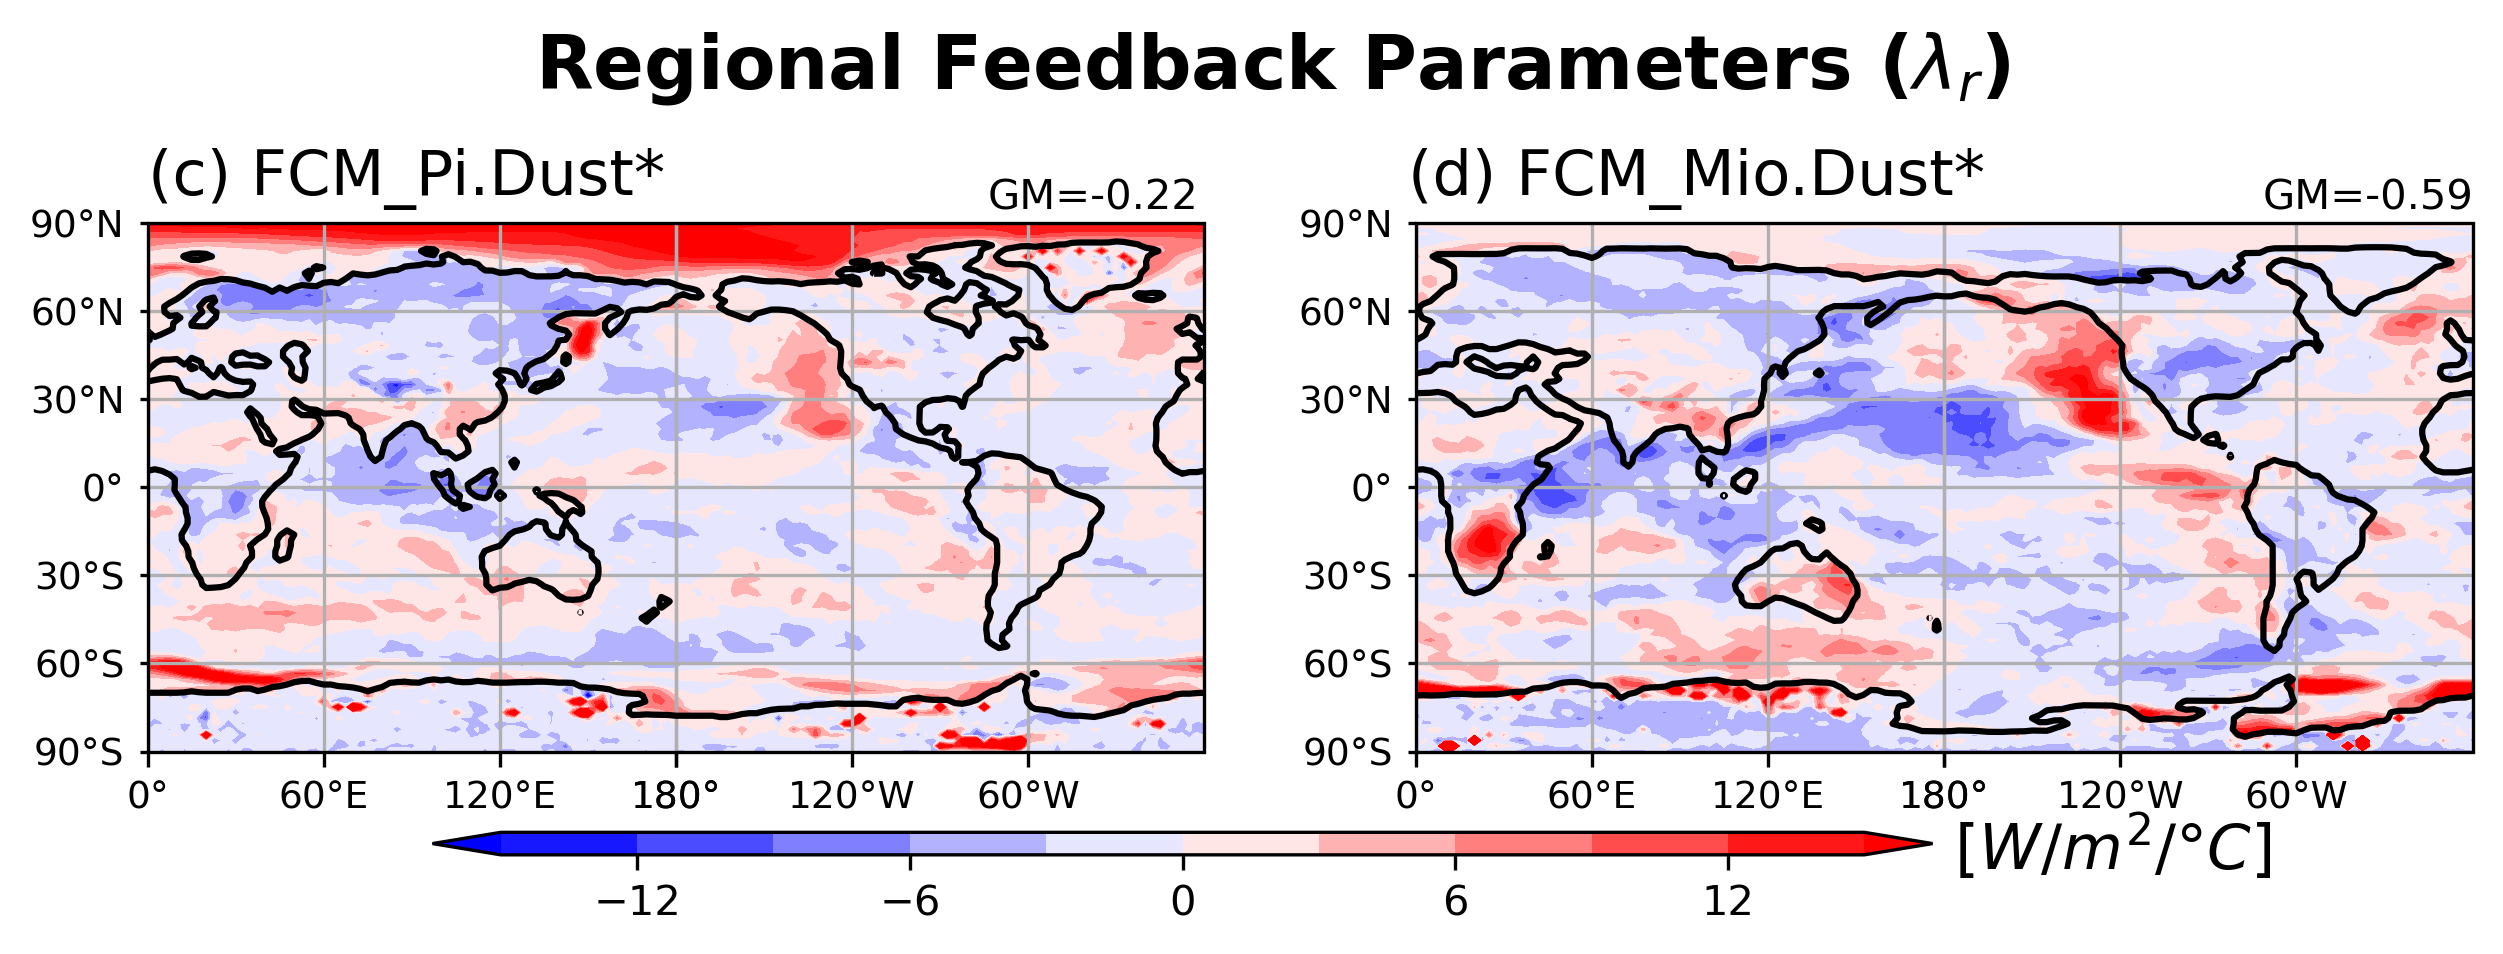

In [15]:
# --- plot ---

# Define the figure and each axis for the 1 rows and 2 columns
fig, axs = plt.subplots(nrows=1,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
                        figsize=(10,5), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.2, hspace=0.1) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(pattern_lambda['pattern']):
        
    # Contour plot
    if i==0:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-15, 15, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    else:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-15, 15, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        # Add coastines in Miocene Scenario
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=4)

    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(9)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(9)        
        
          
    # Add gridlines
    axs[i].gridlines(colors='white', linewidths=0.2, zorder=2)
        
# Add colorbar
cax2 = fig.add_axes([0.22, 0.25, 0.5, 0.015])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')
    
# Add colobar's title
GM_Pi_decadal = 'GM='+str('{:03.2f}'.format(lambda_Pi_after50_10yr_mean.values))
GM_Mio_decadal = 'GM='+str('{:03.2f}'.format(lambda_Mio_after50_10yr_mean.values))

plt.figtext(0.78,0.24,'[$W/m^2/°C$]',ha='center',fontsize=15)
plt.figtext(0.125,0.69,'(c) FCM_Pi.Dust*',fontsize=15)
plt.figtext(0.545,0.69,'(d) FCM_Mio.Dust*',fontsize=15)
plt.figtext(0.405,0.68,GM_Pi_decadal,fontsize=10)
plt.figtext(0.83,0.68,GM_Mio_decadal,fontsize=10)

# Add title
plt.suptitle('Regional Feedback Parameters ($\lambda_r$)', y=0.8, fontsize=18, weight='bold')
# fig.savefig('plot_TS.png')
;